In [3]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Path("diagrams").mkdir(exist_ok=True)

In [4]:
result_path = Path("../thesis_results/downstream_task")
# bias_types = ["less_negative_class", "less_positive_class", "mean_difference"]
bias_types = ["less_positive_class"]
less_bias_strengths = ["0.1"]
mean_bias_strengthts = ["0.8"]
datasets = ["folktables_employment", "folktables_income", "hr_analytics", "breast_cancer", "loan_prediction"]
method_name_replacer = {"mrs-forest": "MRS",  
                        "fw-mrs-temperature_old": "FW-MRS-RF-Abs", "fw-mrs-temperature-svm_old": "FW-MRS-SVM-Abs",
                        "fw-mrs-temperature-svm": "FW-MRS-SVM-Signed", "fw-mrs-temperature": "FW-MRS-RF-Signed",
                          "fw-mrs-temperature-svm_soft_threshold": "FW-MRS-SVM-DA", "fw-mrs-temperature_soft_threshold": "FW-MRS-RF-DA",
                          "mrs-forest_soft_threshold": "MRS-DA",
                          }
data_set_replacer = {"folktables_employment": "Employment", "folktables_income": "Income",
                               "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan"}

## Plot per temperature

In [5]:
dict_list = []
auroc_dict_list = []

for dataset in datasets:
    for bias_type in bias_types:
        for method in method_name_replacer.keys():
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation/dropped_samples_individual_val_dict.json"
                try:
                    dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
                except FileNotFoundError:
                    continue
                auroc_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation"/ "auroc_individual_val_dict.json"
                auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                }
                )

result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
result_df = pd.concat([result_df.drop(['Dropped Samples'], axis=1),result_df["Dropped Samples"].apply(pd.Series)], axis=1)
temperatures = ["0.1", "0.05", "0.01", "0.005"]
result_df = result_df.explode(temperatures)
result_df = result_df.melt(var_name="Temperature", value_name="Dropped Samples", value_vars=temperatures, 
                        id_vars=result_df.drop(columns=temperatures).columns)
auroc_result_df = pd.concat([auroc_result_df.drop(['AUROC'], axis=1), auroc_result_df["AUROC"].apply(pd.Series)], axis=1)
auroc_result_df = auroc_result_df.explode(temperatures)
auroc_result_df = auroc_result_df.melt(var_name="Temperature", value_name="AUROC", value_vars=temperatures)

result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)

## Load MRS

In [6]:
""" mrs_dict_list = []
mrs_auroc_dict_list = []

for dataset in datasets:
    for bias_type in bias_types:
        if bias_type == "mean_difference":
            bias_strengths = mean_bias_strengthts
        else : 
            bias_strengths = less_bias_strengths
        for bias_strength in bias_strengths:
            dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation" / "dropped_samples_individual_val_dict.json"
            auroc_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation"/ "auroc_individual_val_dict.json"
            try:
                dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
            except FileNotFoundError:
                    continue
            auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
            mrs_dict_list.append(
                {
                    "Dropped Samples": dropped_samples_file["0.0"]["0.01"],
                    "Data Set": dataset,
                    "Method": "MRS",
                    "bias_type": bias_type,
                    "bias_strength": bias_strength,
                }
                            )
            mrs_auroc_dict_list.extend(auroc_file["0.0"]["0.01"])
mrs_result_df = pd.DataFrame(data=mrs_dict_list)
mrs_result_df = mrs_result_df.explode("Dropped Samples")
mrs_result_df["Temperature"] = "MRS"
mrs_result_df["AUROC"] = mrs_auroc_dict_list """

' mrs_dict_list = []\nmrs_auroc_dict_list = []\n\nfor dataset in datasets:\n    for bias_type in bias_types:\n        if bias_type == "mean_difference":\n            bias_strengths = mean_bias_strengthts\n        else : \n            bias_strengths = less_bias_strengths\n        for bias_strength in bias_strengths:\n            dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation" / "dropped_samples_individual_val_dict.json"\n            auroc_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation"/ "auroc_individual_val_dict.json"\n            try:\n                dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)\n            except FileNotFoundError:\n                    continue\n            auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)\n            mrs_dict_list.append(\

In [7]:
# result_df = pd.concat([result_df, mrs_result_df], axis=0)
result_df

,Data Set,Method,bias_type,bias_strength,0.0,Temperature,Dropped Samples,AUROC
0,folktables_employment,mrs-forest,less_positive_class,0.1,"{'0.025': [], '0.01': [430, 345, 350, 315, 415...",0.1,NaN,NaN
1,folktables_employment,fw-mrs-temperature_old,less_positive_class,0.1,NaN,0.1,305,0.835317
2,folktables_employment,fw-mrs-temperature_old,less_positive_class,0.1,NaN,0.1,255,0.831602
3,folktables_employment,fw-mrs-temperature_old,less_positive_class,0.1,NaN,0.1,295,0.833242
4,folktables_employment,fw-mrs-temperature_old,less_positive_class,0.1,NaN,0.1,250,0.832768
...,...,...,...,...,...,...,...,...
4027,loan_prediction,fw-mrs-temperature,less_positive_class,0.1,NaN,0.005,21,0.579839
4028,loan_prediction,fw-mrs-temperature,less_positive_class,0.1,NaN,0.005,15,0.745572
4029,loan_prediction,fw-mrs-temperature,less_positive_class,0.1,NaN,0.005,10,0.718876
4030,loan_prediction,fw-mrs-temperature,less_positive_class,0.1,NaN,0.005,8,0.747538


In [8]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df = result_df.replace(method_name_replacer)
result_df = result_df.replace({"folktables_employment": "Employment", "folktables_income": "Income",
                              "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan"})
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

In [9]:
result_df

,Data Set,Method,bias_type,bias_strength,0.0,Temperature,Dropped Samples,AUROC
0,Employment,MRS,less_positive_class,0.1,"{'0.025': [], '0.01': [430, 345, 350, 315, 415...",0.1,NaN,NaN
1,Employment,FW-MRS-RF-Abs,less_positive_class,0.1,NaN,0.1,0.216619,0.835317
2,Employment,FW-MRS-RF-Abs,less_positive_class,0.1,NaN,0.1,0.181108,0.831602
3,Employment,FW-MRS-RF-Abs,less_positive_class,0.1,NaN,0.1,0.209517,0.833242
4,Employment,FW-MRS-RF-Abs,less_positive_class,0.1,NaN,0.1,0.177557,0.832768
...,...,...,...,...,...,...,...,...
4027,Loan,FW-MRS-RF-Signed,less_positive_class,0.1,NaN,0.005,0.291667,0.579839
4028,Loan,FW-MRS-RF-Signed,less_positive_class,0.1,NaN,0.005,0.208333,0.745572
4029,Loan,FW-MRS-RF-Signed,less_positive_class,0.1,NaN,0.005,0.138889,0.718876
4030,Loan,FW-MRS-RF-Signed,less_positive_class,0.1,NaN,0.005,0.111111,0.747538


## With AUROC

In [10]:
""" fig, axes = plt.subplots(2, 1, sharey=True, sharex=False, figsize=(9, 8))
ylabel="Relative Dropped Samples (%)"
sns.set_theme(style="ticks", palette="colorblind")
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-RF"])], y="Dropped Samples", x="Data Set", 
            hue="Temperature", legend=True, hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"],
              ax=axes[0]).set(xlabel="(a) FW-MRS-RF",  ylabel=None)
axes[0].xaxis.get_label().set_visible(True) 
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="Dropped Samples", x="Data Set", 
           hue="Temperature", ax=axes[1], hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"]).set(xlabel="(b) FW-MRS-SVM", ylabel=None)
fig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)
plt.savefig("diagrams/dropped_samples_per_temperature_fixed.pdf") """

' fig, axes = plt.subplots(2, 1, sharey=True, sharex=False, figsize=(9, 8))\nylabel="Relative Dropped Samples (%)"\nsns.set_theme(style="ticks", palette="colorblind")\nsns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-RF"])], y="Dropped Samples", x="Data Set", \n            hue="Temperature", legend=True, hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"],\n              ax=axes[0]).set(xlabel="(a) FW-MRS-RF",  ylabel=None)\naxes[0].xaxis.get_label().set_visible(True) \nsns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="Dropped Samples", x="Data Set", \n           hue="Temperature", ax=axes[1], hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"]).set(xlabel="(b) FW-MRS-SVM", ylabel=None)\nfig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)\nplt.savefig("diagrams/dropped_samples_per_temperature_fixed.pdf") '

In [11]:
""" fig, axes = plt.subplots(2, 1, sharey=True, sharex=False, figsize=(9, 8))
ylabel="AUROC"
sns.set_theme(style="ticks", palette="colorblind")
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-RF"])], y="AUROC", x="Data Set", 
            hue="Temperature", legend=True, hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"],
              ax=axes[0]).set(xlabel="(a) FW-MRS-RF",  ylabel=None)
axes[0].xaxis.get_label().set_visible(True) 
sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="AUROC", x="Data Set", 
           hue="Temperature", ax=axes[1], hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"]).set(xlabel="(b) FW-MRS-SVM", ylabel=None)
fig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)
plt.savefig("diagrams/auroc_per_temperature_fixed.pdf") """

' fig, axes = plt.subplots(2, 1, sharey=True, sharex=False, figsize=(9, 8))\nylabel="AUROC"\nsns.set_theme(style="ticks", palette="colorblind")\nsns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-RF"])], y="AUROC", x="Data Set", \n            hue="Temperature", legend=True, hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"],\n              ax=axes[0]).set(xlabel="(a) FW-MRS-RF",  ylabel=None)\naxes[0].xaxis.get_label().set_visible(True) \nsns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS-SVM"])], y="AUROC", x="Data Set", \n           hue="Temperature", ax=axes[1], hue_order=["MRS", "0.1", "0.05", "0.01", "0.005"]).set(xlabel="(b) FW-MRS-SVM", ylabel=None)\nfig.text(0.05,0.5, ylabel, ha="center", va="center", rotation=90)\nplt.savefig("diagrams/auroc_per_temperature_fixed.pdf") '

## Plot per method

In [12]:
aurocs = []
auprcs = []
dict_list = []
auroc_dict_list = []
for dataset in datasets:
    for bias_type in bias_types:
        for method in method_name_replacer.keys():
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                dropped_samples_file = result_path / dataset / bias_type /  bias_strength/ method / "classification_results" / "dropped_samples.json"
                auroc_file_name = result_path / dataset / bias_type /  bias_strength/ method / "classification_results"/ "rf_auroc.json"
                try:
                    dropped_samples_file = pd.read_json(str(dropped_samples_file), typ="series")
                    auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                except FileNotFoundError:
                    continue
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                    }
                                )
result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
auroc_result_df = auroc_result_df.explode(column="AUROC", ignore_index=True)
result_df = result_df.explode(column="Dropped Samples", ignore_index=True)
result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)
#result_df = pd.concat([result_df, mrs_result_df], axis=0)
result_df = result_df.replace(method_name_replacer)
result_df = result_df.replace(data_set_replacer)
# result_df = result_df.drop(columns=["Temperature"])

In [13]:
result_df

,Dropped Samples,Data Set,Method,bias_type,bias_strength,AUROC
0,225,Employment,MRS,less_positive_class,0.1,0.870584
1,150,Employment,MRS,less_positive_class,0.1,0.888492
2,165,Employment,MRS,less_positive_class,0.1,0.867395
3,105,Employment,MRS,less_positive_class,0.1,0.877698
4,185,Employment,MRS,less_positive_class,0.1,0.859123
...,...,...,...,...,...,...
1595,5,Loan,MRS-DA,less_positive_class,0.1,0.495455
1596,1,Loan,MRS-DA,less_positive_class,0.1,0.716667
1597,8,Loan,MRS-DA,less_positive_class,0.1,0.752020
1598,1,Loan,MRS-DA,less_positive_class,0.1,0.683479


In [14]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

## Test Results

In [15]:
list(method_name_replacer.values())

['MRS',
 'FW-MRS-RF-Abs',
 'FW-MRS-SVM-Abs',
 'FW-MRS-SVM-Signed',
 'FW-MRS-RF-Signed',
 'FW-MRS-SVM-DA',
 'FW-MRS-RF-DA',
 'MRS-DA']

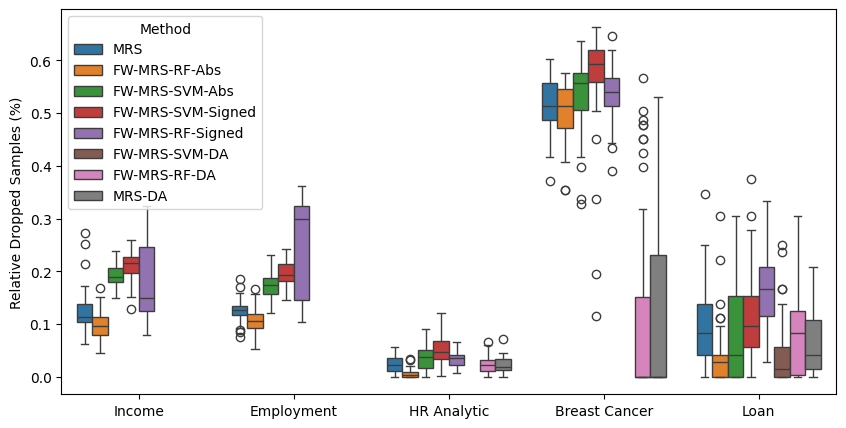

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=result_df, y="Dropped Samples", x="Data Set", hue="Method",
            order=["Income", "Employment", "HR Analytic", "Breast Cancer", "Loan"],
            hue_order=method_name_replacer.values()).set(xlabel=None, ylabel="Relative Dropped Samples (%)")
plt.savefig("diagrams/relative_dropped_samples_per_method_complete.pdf", bbox_inches="tight")

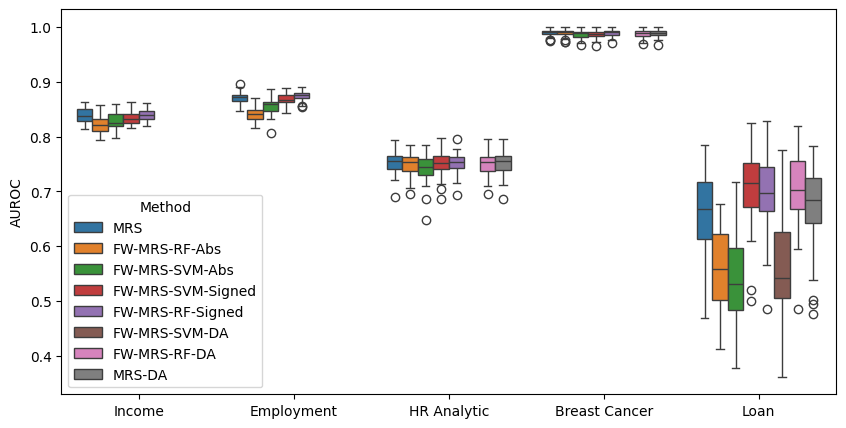

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=result_df, y="AUROC", x="Data Set", hue="Method",
            order=["Income", "Employment", "HR Analytic", "Breast Cancer", "Loan"],
            hue_order=method_name_replacer.values()).set(xlabel=None, ylabel="AUROC")
plt.savefig("diagrams/auroc_samples_per_method_complete.pdf", bbox_inches="tight")